# Shopee Price Match Guarantee — leakage-aware EDA

This notebook is a bounded, reproducible companion to the executable Phase 1 audit. It does not replace `shopee-data prepare`, does not alter labels, and does not write raw records into tracked reports. Outputs are intentionally cleared before commit.

Questions: What does one product group look like? Which title/image signals are useful? Where do exact collisions cross labels? Does the frozen split remain group-disjoint? Which failure categories should later models target?

## 1. Setup

The notebook uses the standard library, OpenCV, NumPy, Matplotlib, and IPython supplied by the `eda` environment. Image work is sampled with a fixed seed so opening the notebook does not decode all 32k files.

In [22]:
from __future__ import annotations

import base64
import csv
import hashlib
import html
import json
import random
import re
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

SEED = 2026
IMAGE_SAMPLE_SIZE = 512
EXPECTED_METADATA_SHA256 = "82b8ec57e81b603e00c63779b7eeea69a2bd7d9cbb48377657cf547b422f9175"
EXPECTED_MANIFEST_SHA256 = "c9cef390b5fbde6c833fddb15a0a8df2c7fbecacd8d50fb83aadba6056bf8e09"
CHART_COLORS = ["#2563EB", "#0F766E", "#D97706", "#DC2626", "#7C3AED"]
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "figure.dpi": 110,
        "font.size": 10,
    }
)


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Open this notebook from inside the project checkout")


ROOT = find_project_root(Path.cwd())
METADATA = ROOT / "data/raw/train.csv"
IMAGES = ROOT / "data/raw/train_images"
MANIFEST = ROOT / "data/splits/shopee_group_split_v1.jsonl"
ROOT

WindowsPath('C:/Users/ADMIN/Documents/Shopee-Price-Match-Guarantee-Competition')

## 2. Load immutable metadata and frozen split

The checksum assertions prevent this notebook from silently describing a different release or split.

In [23]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


assert METADATA.exists() and IMAGES.is_dir() and MANIFEST.exists()
assert sha256_file(METADATA) == EXPECTED_METADATA_SHA256
assert sha256_file(MANIFEST) == EXPECTED_MANIFEST_SHA256

with METADATA.open("r", encoding="utf-8-sig", newline="") as handle:
    rows = list(csv.DictReader(handle))
with MANIFEST.open("r", encoding="utf-8") as handle:
    manifest = [json.loads(line) for line in handle]

by_id = {row["posting_id"]: row for row in rows}
split_by_id = {record["posting_id"]: record["split"] for record in manifest}
assert len(by_id) == len(rows)
assert set(by_id) == set(split_by_id)
print(f"Loaded {len(rows):,} listings and {len(set(r['label_group'] for r in rows)):,} groups")

Loaded 34,250 listings and 11,014 groups


## 3. Schema, missingness, and group-size distribution

In [24]:
REQUIRED_COLUMNS = {"posting_id", "image", "image_phash", "title", "label_group"}
assert set(rows[0]) == REQUIRED_COLUMNS
missing = {column: sum(not row[column].strip() for row in rows) for column in REQUIRED_COLUMNS}
group_sizes = Counter(row["label_group"] for row in rows)


def percentile(values: list[float], q: float) -> float:
    return float(np.percentile(np.asarray(values, dtype=np.float64), q))


summary = {
    "rows": len(rows),
    "groups": len(group_sizes),
    "missing": missing,
    "duplicate_posting_ids": len(rows) - len(by_id),
    "group_size_min": min(group_sizes.values()),
    "group_size_median": percentile(list(group_sizes.values()), 50),
    "group_size_p95": percentile(list(group_sizes.values()), 95),
    "group_size_max": max(group_sizes.values()),
}
display(summary)
display(Counter(group_sizes.values()).most_common(12))

{'rows': 34250,
 'groups': 11014,
 'missing': {'posting_id': 0,
  'title': 0,
  'label_group': 0,
  'image': 0,
  'image_phash': 0},
 'duplicate_posting_ids': 0,
 'group_size_min': 2,
 'group_size_median': 2.0,
 'group_size_p95': 7.0,
 'group_size_max': 51}

[(2, 6979),
 (3, 1779),
 (4, 862),
 (5, 468),
 (6, 282),
 (7, 154),
 (8, 118),
 (9, 91),
 (10, 48),
 (12, 39),
 (11, 38),
 (13, 28)]

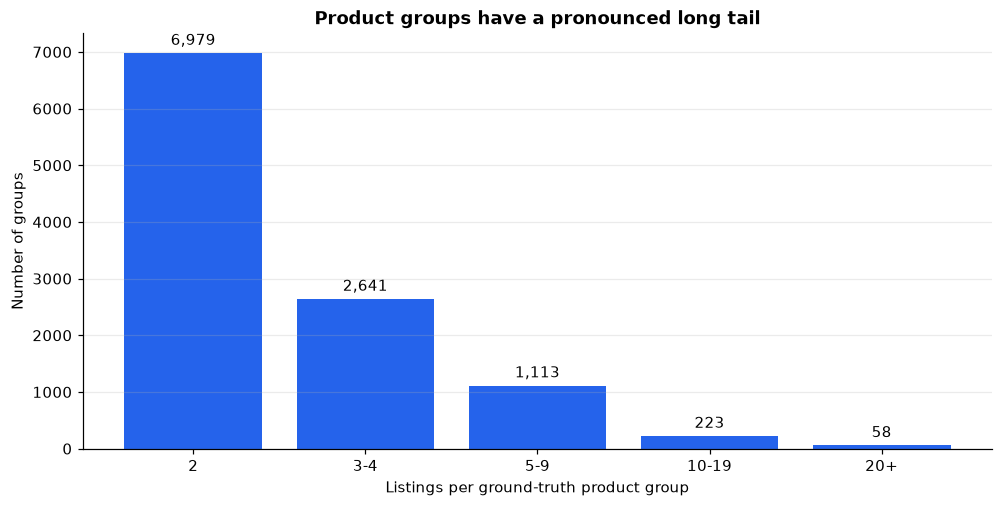

In [25]:
group_size_bands = {
    "2": sum(size == 2 for size in group_sizes.values()),
    "3-4": sum(3 <= size <= 4 for size in group_sizes.values()),
    "5-9": sum(5 <= size <= 9 for size in group_sizes.values()),
    "10-19": sum(10 <= size <= 19 for size in group_sizes.values()),
    "20+": sum(size >= 20 for size in group_sizes.values()),
}
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
bars = ax.bar(list(group_size_bands), list(group_size_bands.values()), color=CHART_COLORS[0])
ax.bar_label(bars, labels=[f"{value:,}" for value in group_size_bands.values()], padding=3)
ax.set(
    title="Product groups have a pronounced long tail",
    xlabel="Listings per ground-truth product group",
    ylabel="Number of groups",
)
ax.grid(axis="y", alpha=0.25)
plt.show()

## 4. Title diagnostics

Digits and units are identity-critical, so normalization deliberately preserves them. Exact normalized-title collisions across labels are audit signals, not automatic merges.

In [26]:
def normalize_title(value: str) -> str:
    normalized = unicodedata.normalize("NFKC", value).casefold()
    return " ".join(re.sub(r"[^\w]+", " ", normalized).split())


title_lengths = [len(row["title"]) for row in rows]
token_counts = [len(normalize_title(row["title"]).split()) for row in rows]
normalized_title_labels: dict[str, set[str]] = defaultdict(set)
for row in rows:
    normalized_title_labels[normalize_title(row["title"])].add(row["label_group"])

title_summary = {
    "characters_median": percentile(title_lengths, 50),
    "characters_p95": percentile(title_lengths, 95),
    "tokens_median": percentile(token_counts, 50),
    "tokens_p95": percentile(token_counts, 95),
    "titles_with_digits": sum(any(char.isdigit() for char in row["title"]) for row in rows),
    "normalized_titles_crossing_labels": sum(
        len(labels) > 1 for labels in normalized_title_labels.values()
    ),
}
display(title_summary)

{'characters_median': 53.0,
 'characters_p95': 98.0,
 'tokens_median': 9.0,
 'tokens_p95': 16.0,
 'titles_with_digits': 20206,
 'normalized_titles_crossing_labels': 119}

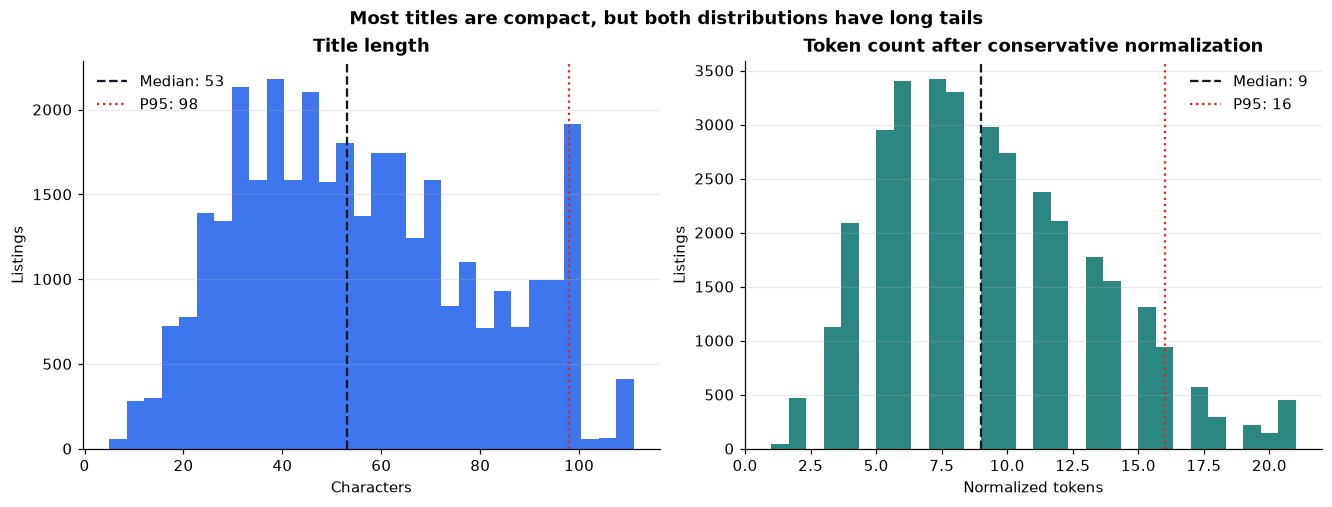

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, values, label, color in (
    (axes[0], title_lengths, "Characters", CHART_COLORS[0]),
    (axes[1], token_counts, "Normalized tokens", CHART_COLORS[1]),
):
    upper = percentile(values, 99)
    clipped = [min(value, upper) for value in values]
    ax.hist(clipped, bins=30, color=color, alpha=0.88)
    median = percentile(values, 50)
    p95 = percentile(values, 95)
    ax.axvline(median, color="#111827", linestyle="--", label=f"Median: {median:.0f}")
    ax.axvline(p95, color="#DC2626", linestyle=":", label=f"P95: {p95:.0f}")
    ax.set(xlabel=label, ylabel="Listings")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
axes[0].set_title("Title length")
axes[1].set_title("Token count after conservative normalization")
fig.suptitle("Most titles are compact, but both distributions have long tails", fontweight="bold")
plt.show()

## 5. Supplied pHash collisions

An exact pHash is evidence of similar appearance, not proof of the same purchasable product. Variant size, quantity, color, and packaging must still be checked.

In [28]:
phash_rows: dict[str, list[dict[str, str]]] = defaultdict(list)
for row in rows:
    phash_rows[row["image_phash"]].append(row)

phash_summary = {
    "unique_phashes": len(phash_rows),
    "repeated_phash_buckets": sum(len(items) > 1 for items in phash_rows.values()),
    "exact_phash_buckets_crossing_labels": sum(
        len({item["label_group"] for item in items}) > 1 for items in phash_rows.values()
    ),
}
display(phash_summary)

{'unique_phashes': 28735,
 'repeated_phash_buckets': 3229,
 'exact_phash_buckets_crossing_labels': 147}

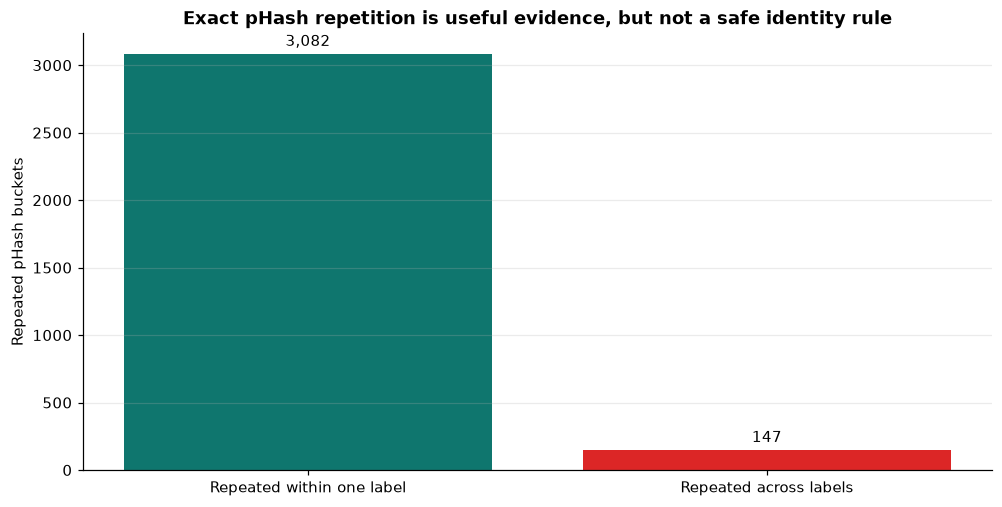

In [29]:
cross_label_buckets = phash_summary["exact_phash_buckets_crossing_labels"]
same_label_buckets = phash_summary["repeated_phash_buckets"] - cross_label_buckets
collision_counts = {
    "Repeated within one label": same_label_buckets,
    "Repeated across labels": cross_label_buckets,
}
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
bars = ax.bar(
    list(collision_counts),
    list(collision_counts.values()),
    color=[CHART_COLORS[1], CHART_COLORS[3]],
)
ax.bar_label(bars, labels=[f"{value:,}" for value in collision_counts.values()], padding=3)
ax.set(
    title="Exact pHash repetition is useful evidence, but not a safe identity rule",
    ylabel="Repeated pHash buckets",
)
ax.grid(axis="y", alpha=0.25)
plt.show()

## 6. Frozen split integrity

Every label group must occur in exactly one split. Phase 1 additionally linked groups sharing exact image references, SHA-256 bytes, or exact pHash before assignment.

In [30]:
label_splits: dict[str, set[str]] = defaultdict(set)
split_counts = Counter()
split_groups: dict[str, set[str]] = defaultdict(set)
for row in rows:
    split = split_by_id[row["posting_id"]]
    label_splits[row["label_group"]].add(split)
    split_counts[split] += 1
    split_groups[split].add(row["label_group"])

assert all(len(splits) == 1 for splits in label_splits.values())
display(
    {
        split: {"listings": split_counts[split], "groups": len(split_groups[split])}
        for split in ("train", "validation", "test")
    }
)

{'train': {'listings': 27391, 'groups': 8817},
 'validation': {'listings': 3430, 'groups': 1100},
 'test': {'listings': 3429, 'groups': 1097}}

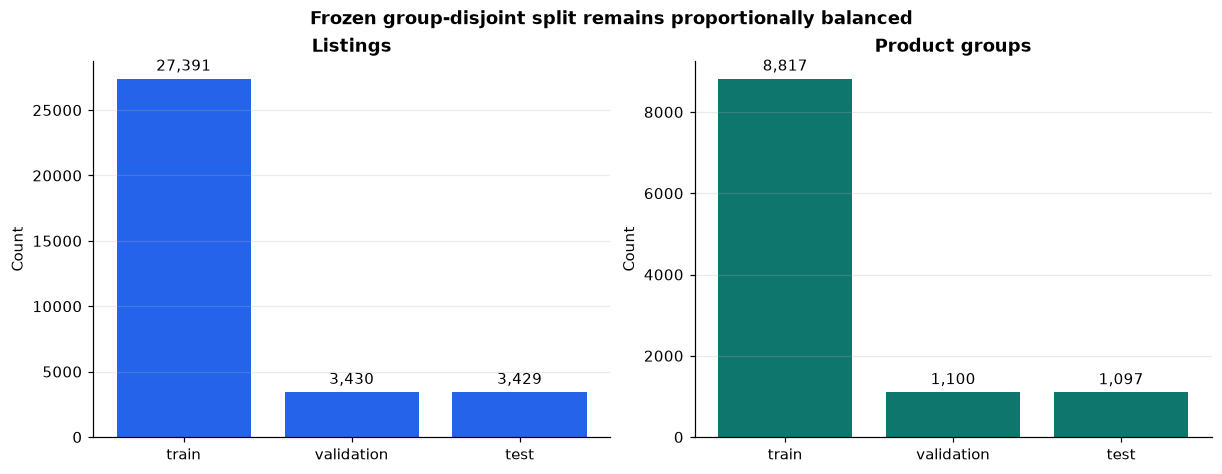

In [31]:
split_order = ["train", "validation", "test"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, values, title, color in (
    (axes[0], [split_counts[name] for name in split_order], "Listings", CHART_COLORS[0]),
    (axes[1], [len(split_groups[name]) for name in split_order], "Product groups", CHART_COLORS[1]),
):
    bars = ax.bar(split_order, values, color=color)
    ax.bar_label(bars, labels=[f"{value:,}" for value in values], padding=3)
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Frozen group-disjoint split remains proportionally balanced", fontweight="bold")
plt.show()

## 7. Bounded image decode and geometry sample

The executable audit validates every referenced image. This notebook samples only for interactive diagnostics.

In [32]:
unique_images = sorted({row["image"] for row in rows})
rng = random.Random(SEED)
sample_names = rng.sample(unique_images, min(IMAGE_SAMPLE_SIZE, len(unique_images)))
widths, heights, aspect_ratios = [], [], []
decode_failures = []
for name in sample_names:
    image = cv2.imread(str(IMAGES / name), cv2.IMREAD_COLOR)
    if image is None:
        decode_failures.append(name)
        continue
    height, width = image.shape[:2]
    widths.append(width)
    heights.append(height)
    aspect_ratios.append(width / height)

display(
    {
        "sample_size": len(sample_names),
        "decode_failures": len(decode_failures),
        "width_median": percentile(widths, 50),
        "height_median": percentile(heights, 50),
        "aspect_ratio_p05_p95": (percentile(aspect_ratios, 5), percentile(aspect_ratios, 95)),
    }
)

{'sample_size': 512,
 'decode_failures': 0,
 'width_median': 640.0,
 'height_median': 640.0,
 'aspect_ratio_p05_p95': (1.0, 1.0)}

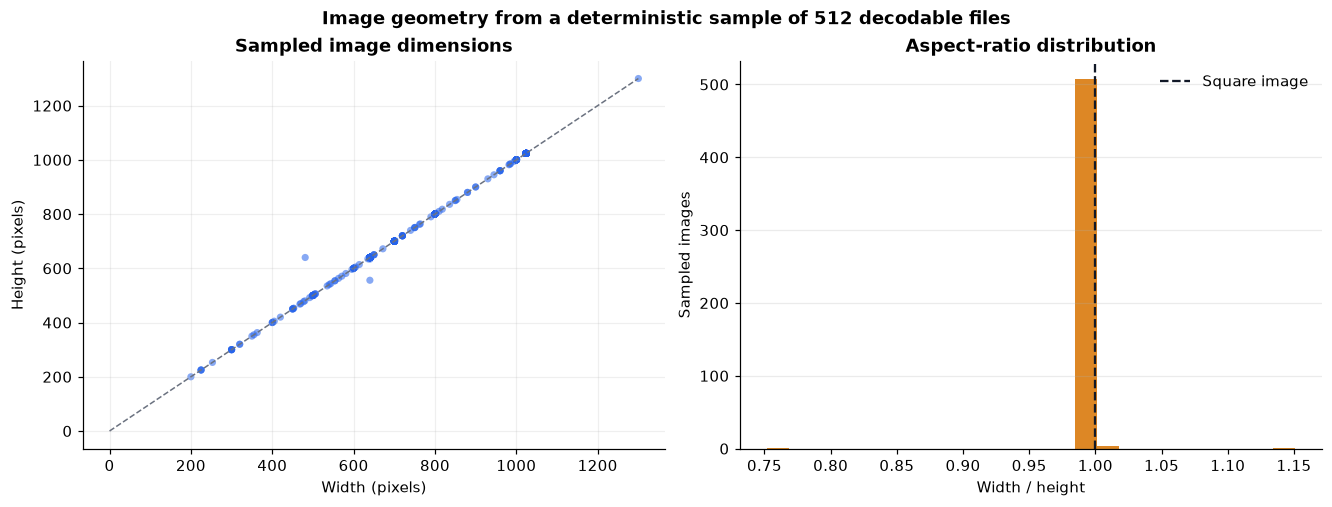

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].scatter(widths, heights, s=22, alpha=0.55, color=CHART_COLORS[0], edgecolors="none")
limit = max(max(widths), max(heights))
axes[0].plot([0, limit], [0, limit], color="#6B7280", linestyle="--", linewidth=1)
axes[0].set(
    title="Sampled image dimensions",
    xlabel="Width (pixels)",
    ylabel="Height (pixels)",
)
axes[0].grid(alpha=0.2)
axes[1].hist(aspect_ratios, bins=24, color=CHART_COLORS[2], alpha=0.88)
axes[1].axvline(1.0, color="#111827", linestyle="--", label="Square image")
axes[1].set(
    title="Aspect-ratio distribution",
    xlabel="Width / height",
    ylabel="Sampled images",
)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(frameon=False)
fig.suptitle(
    f"Image geometry from a deterministic sample of {len(widths):,} decodable files",
    fontweight="bold",
)
plt.show()

## 8. Deterministic visual review

The HTML is generated only in memory. Clear outputs before committing the notebook so competition images and titles are not embedded in Git.


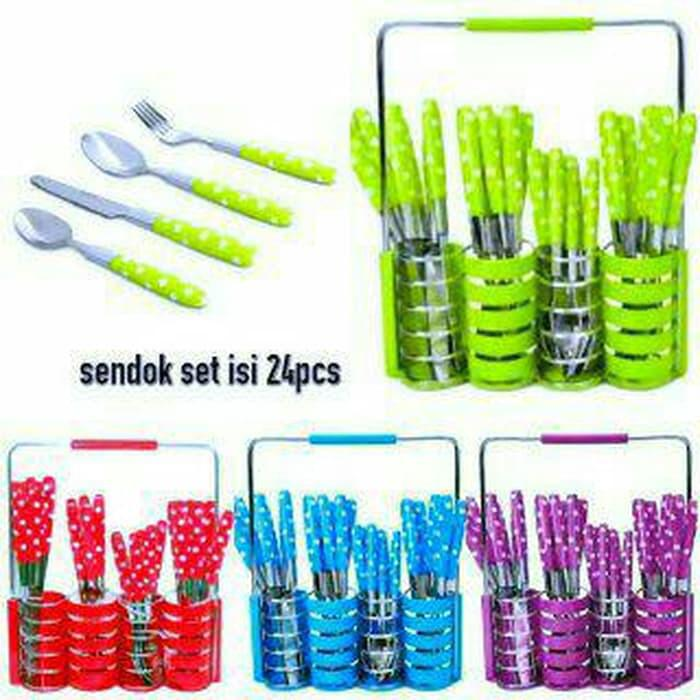
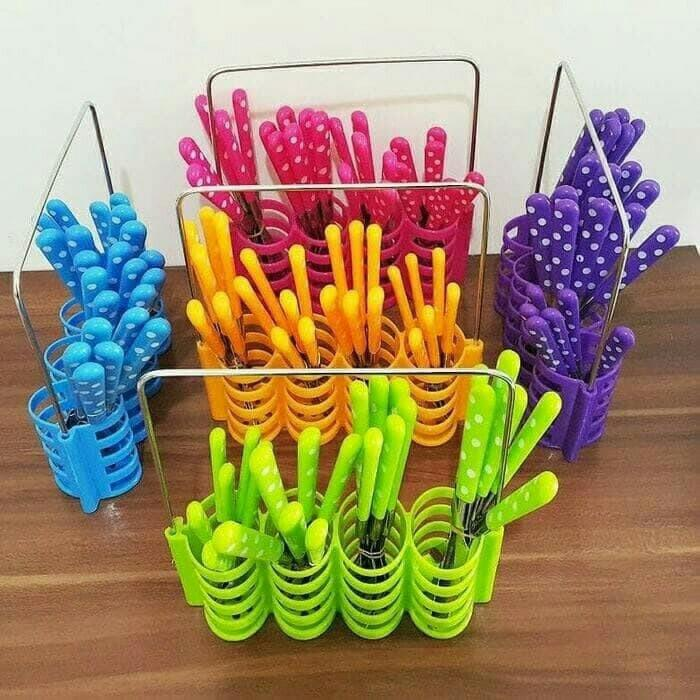
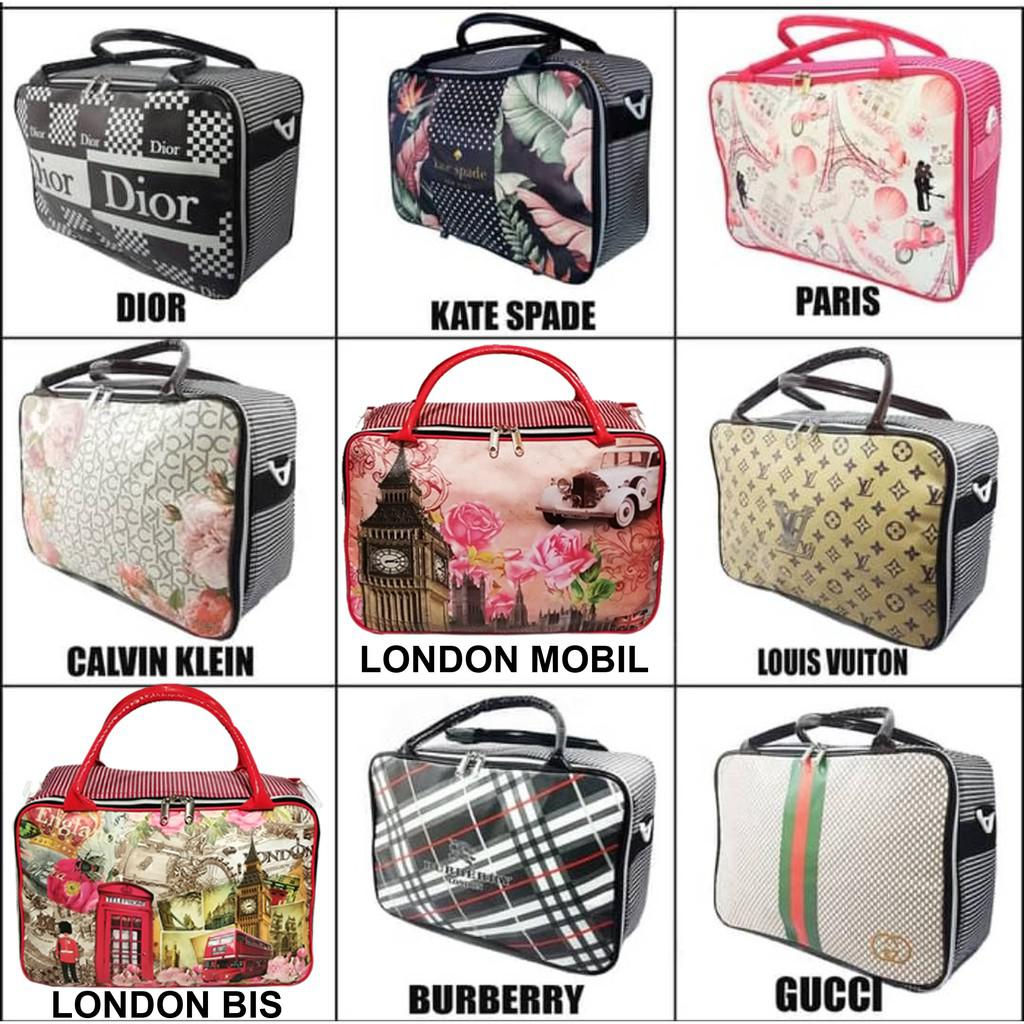
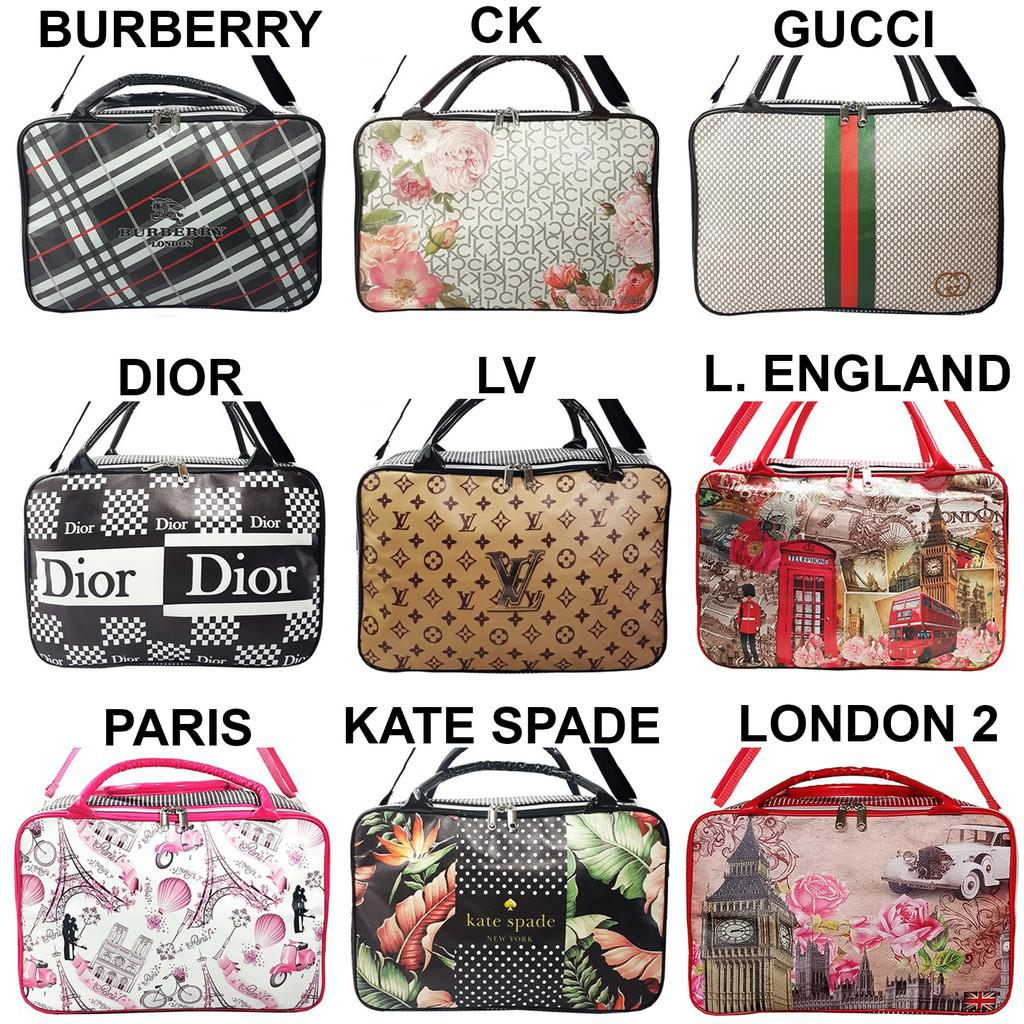
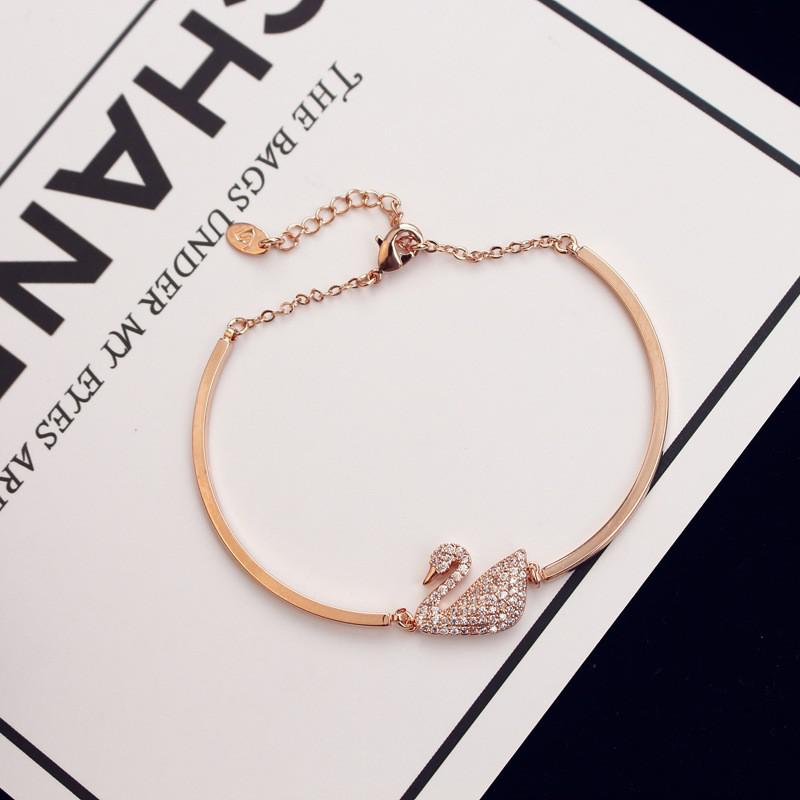
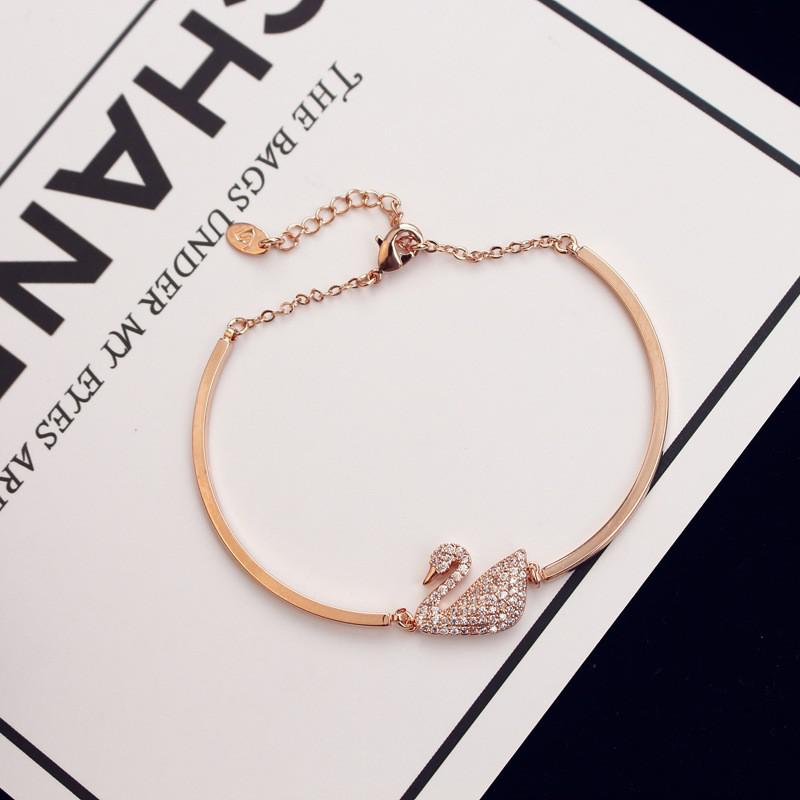
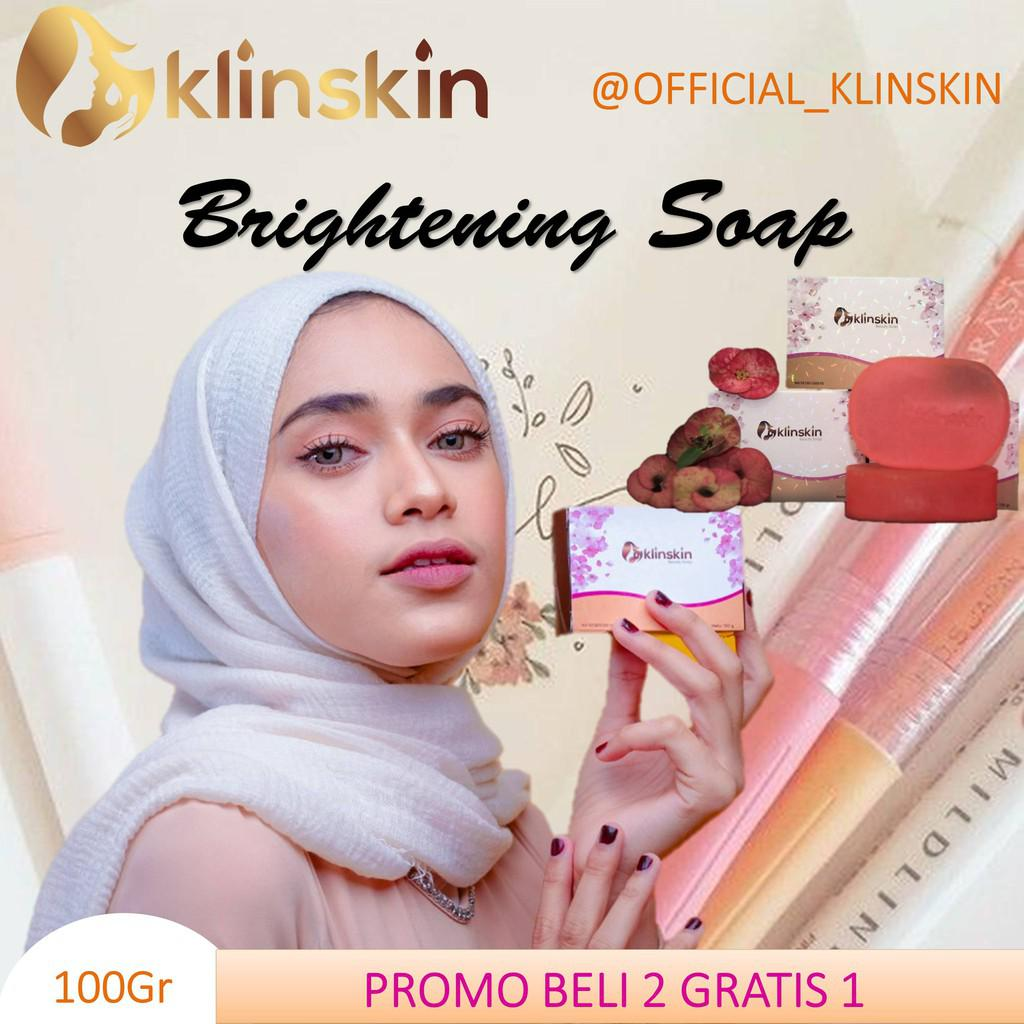
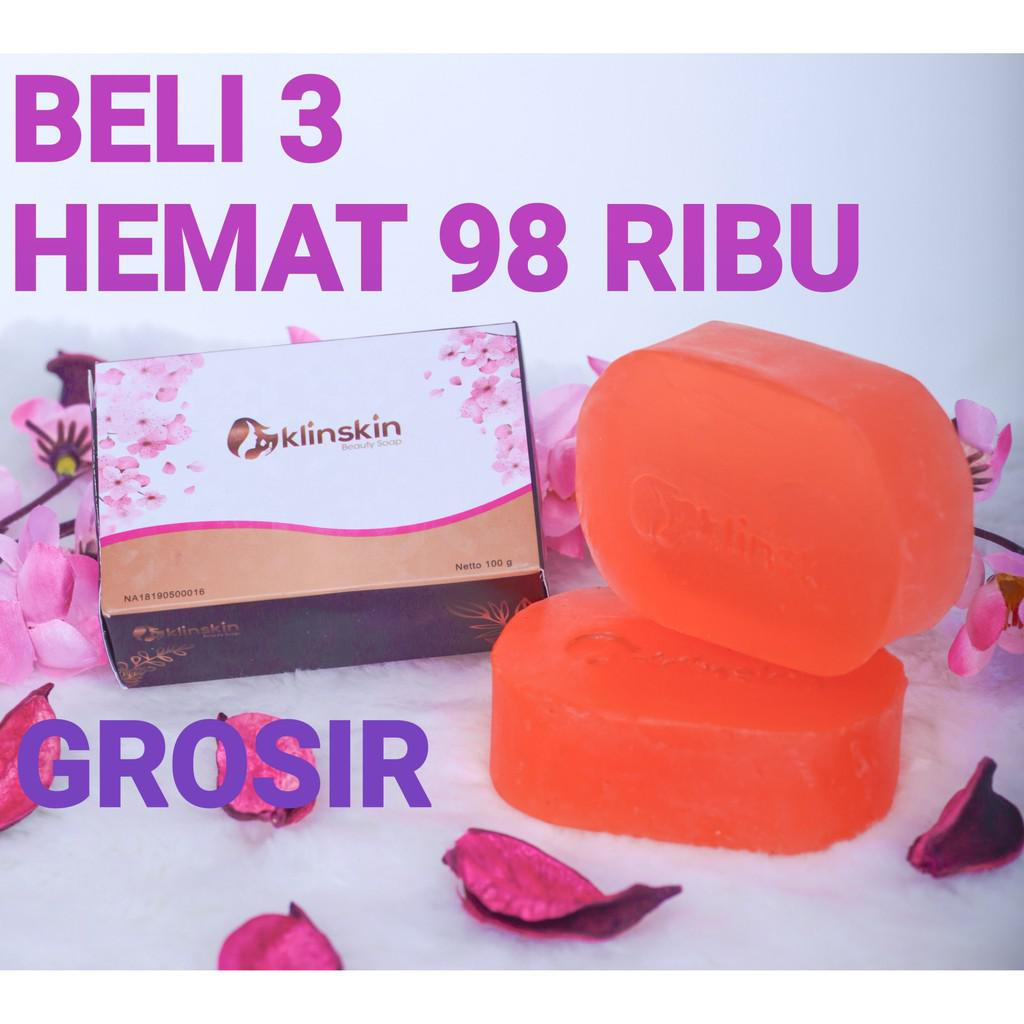
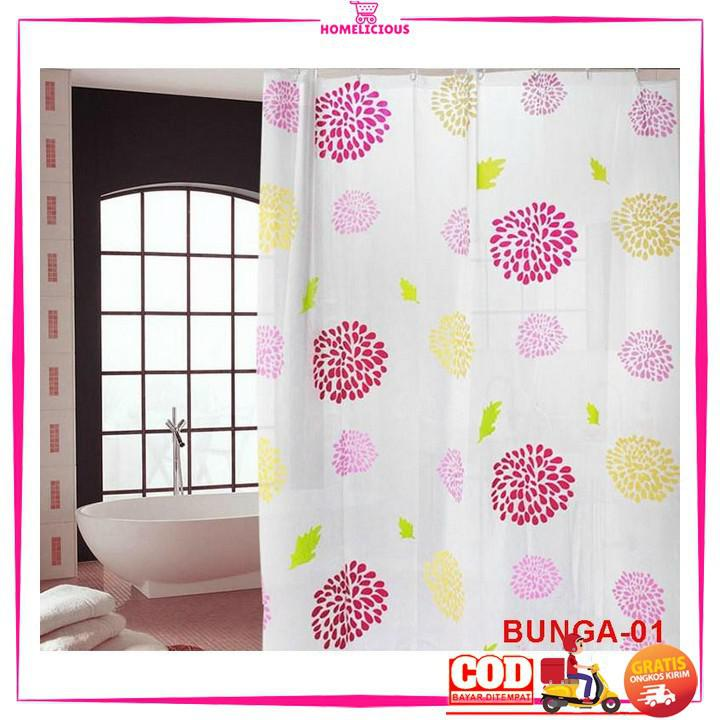
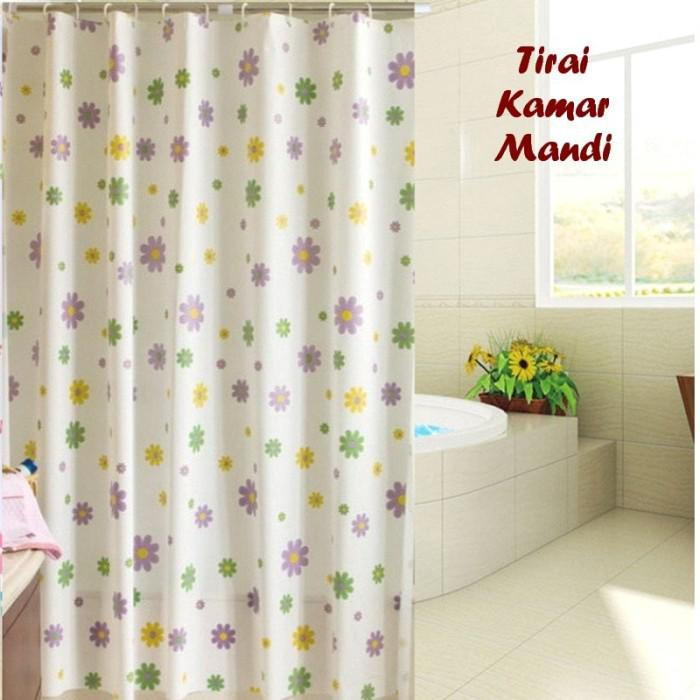
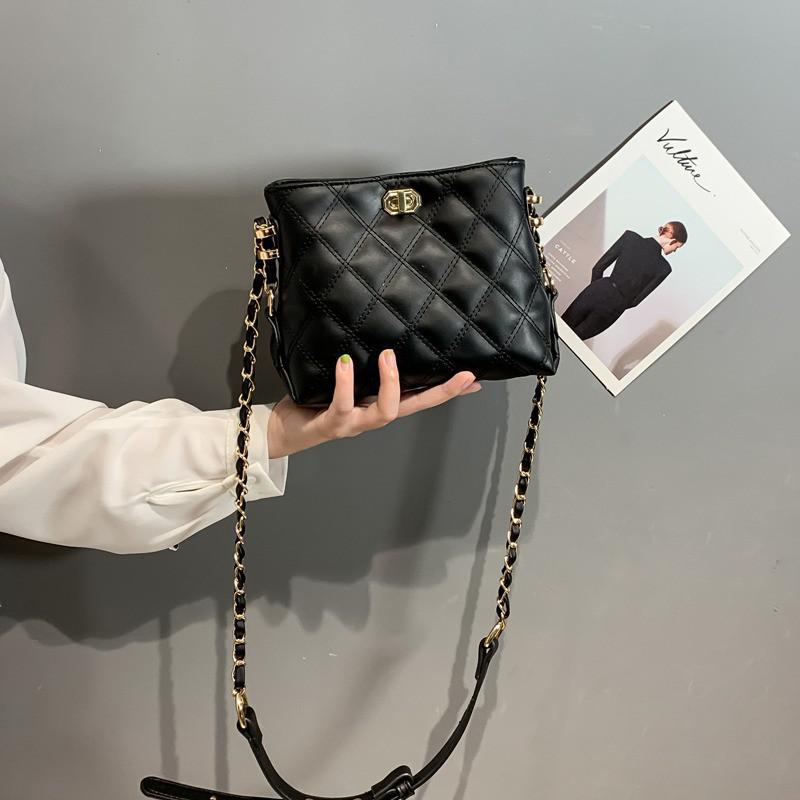
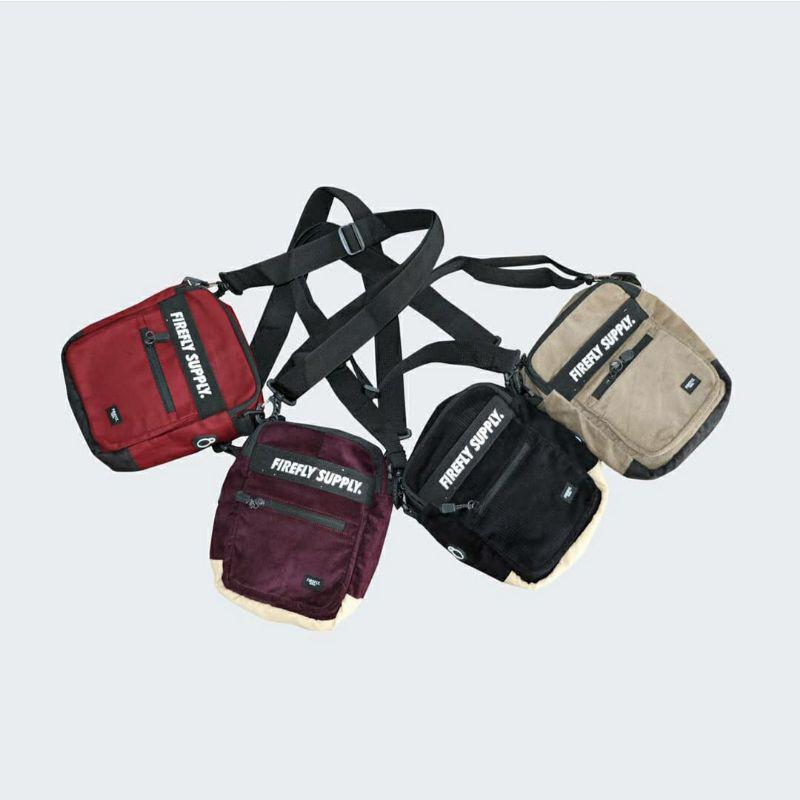


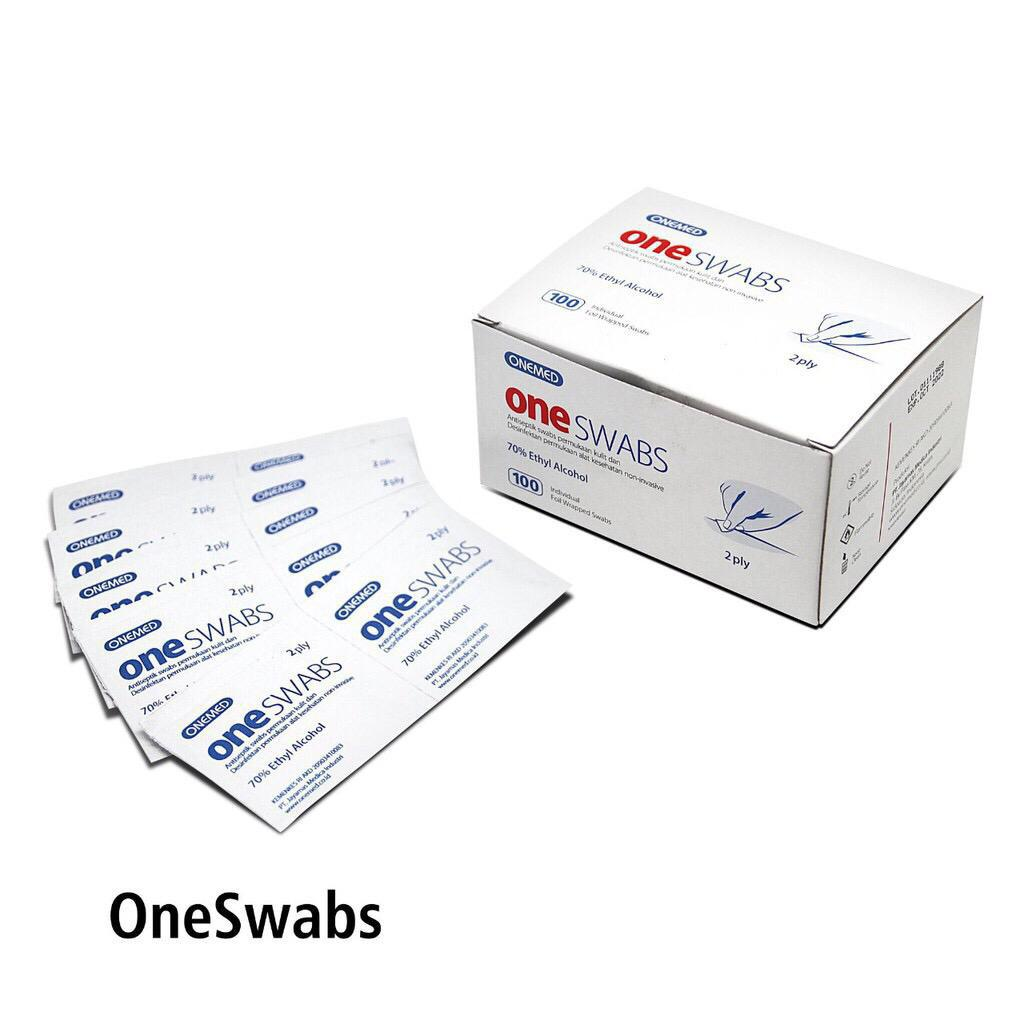
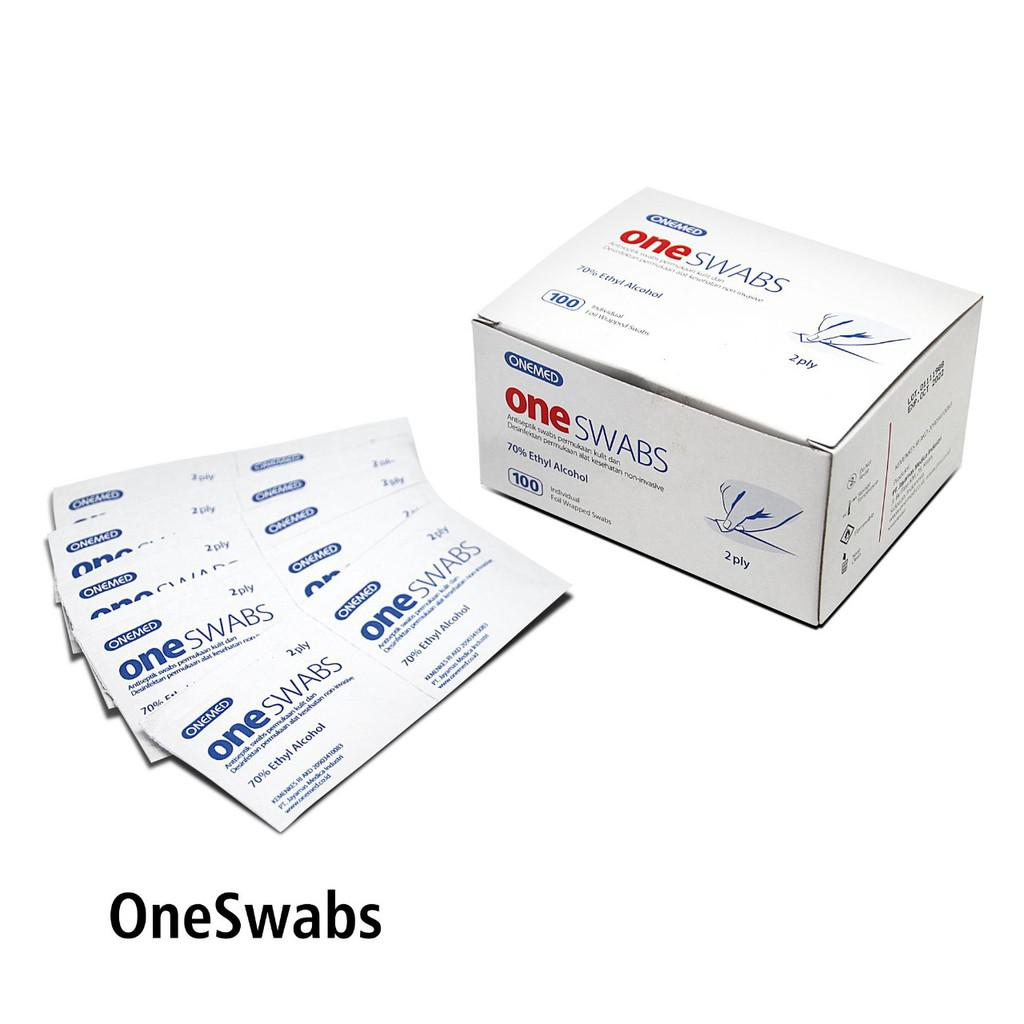
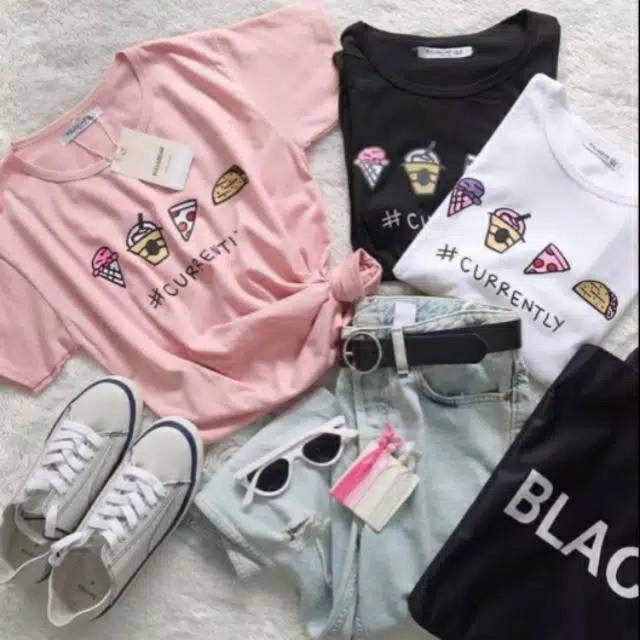
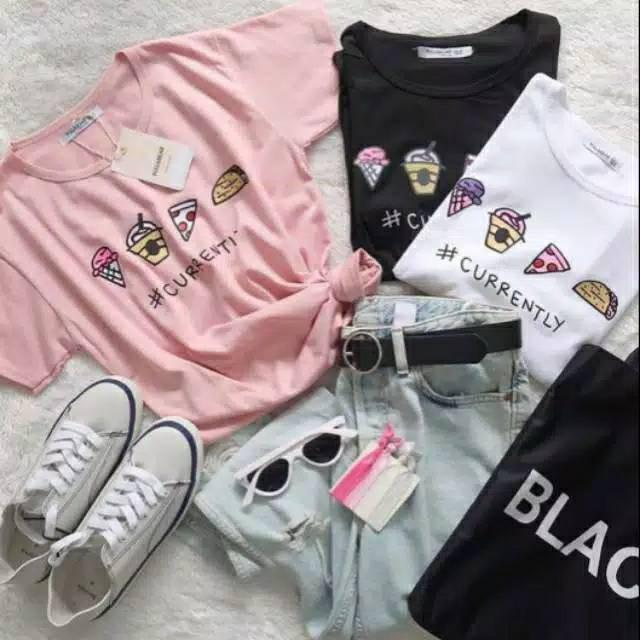
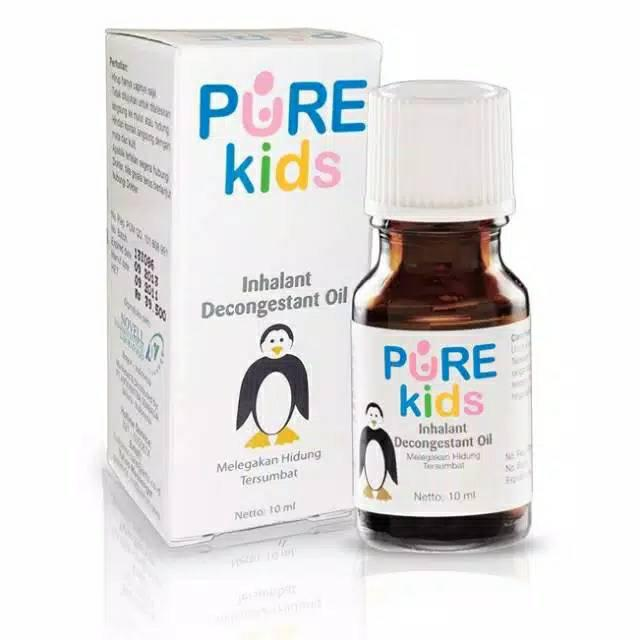
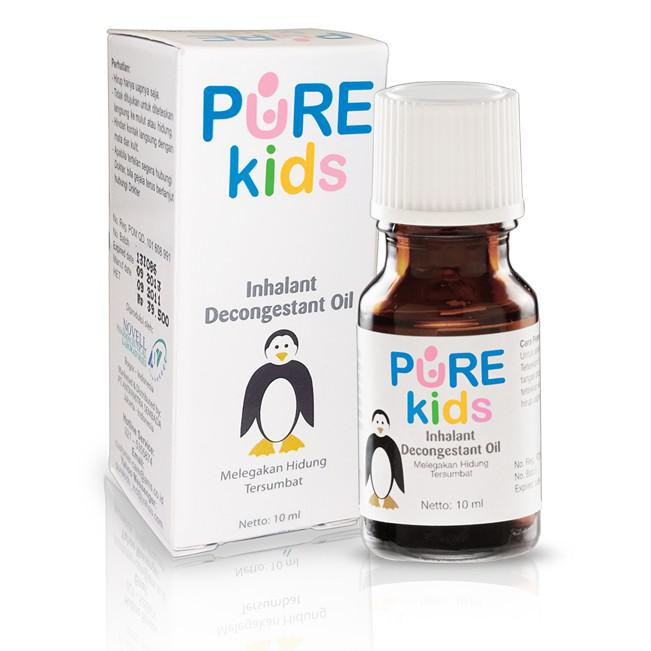
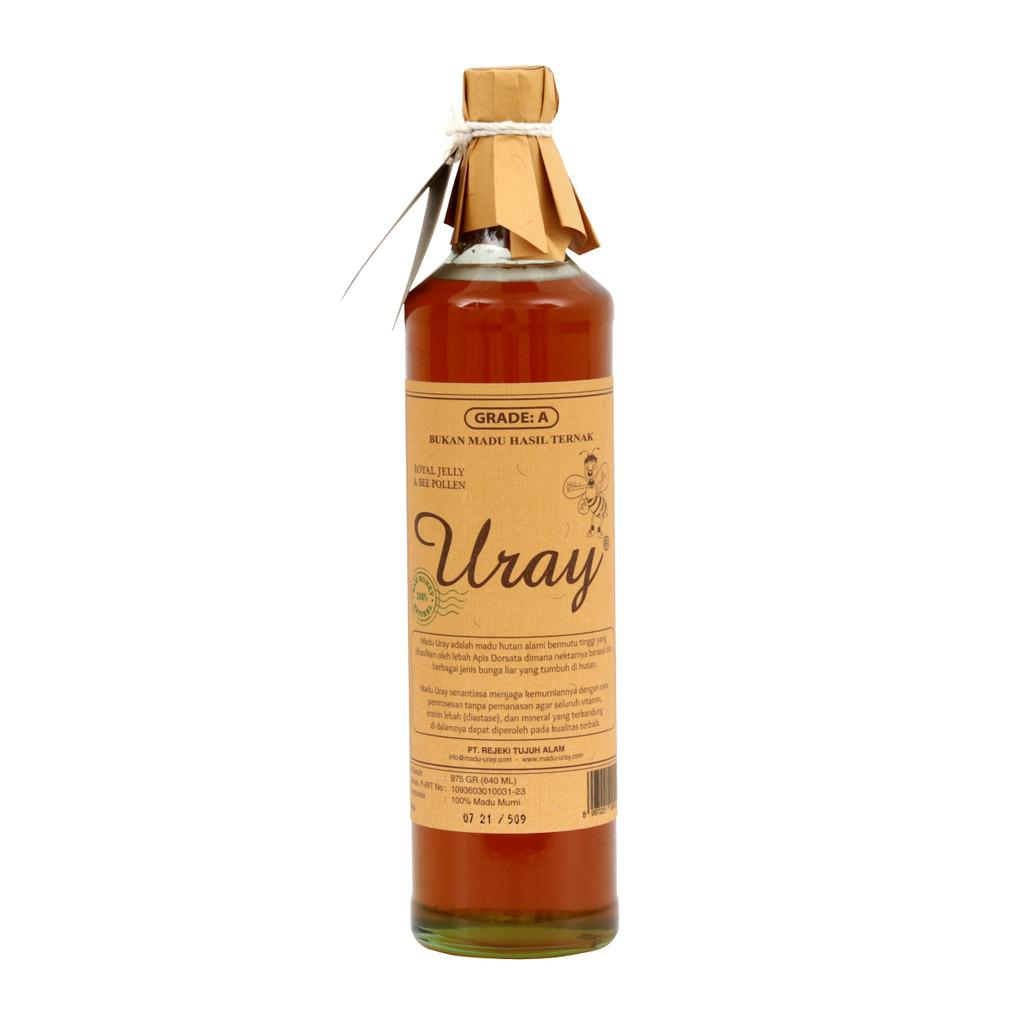
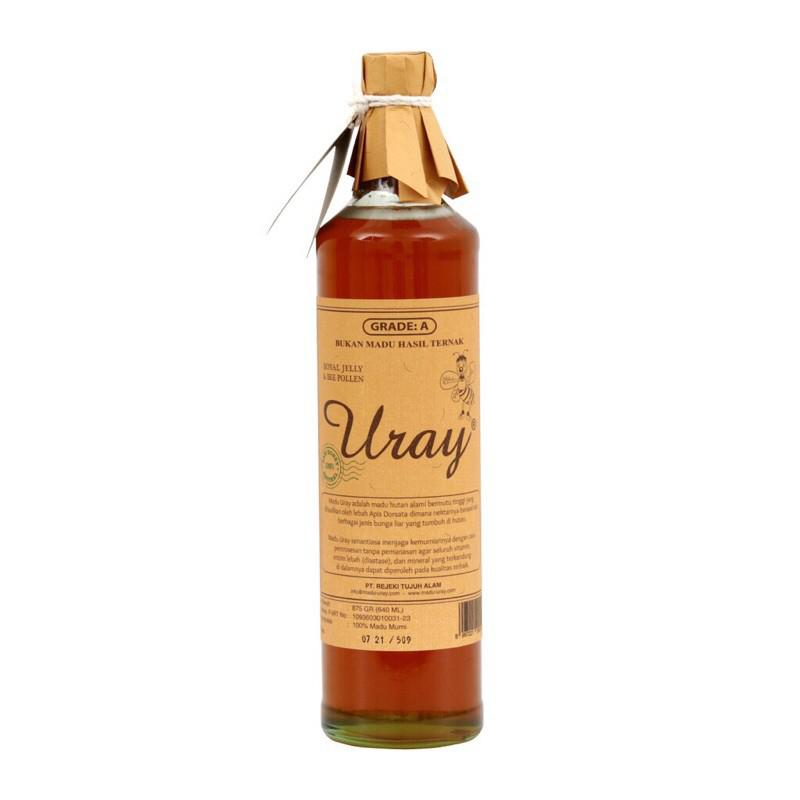
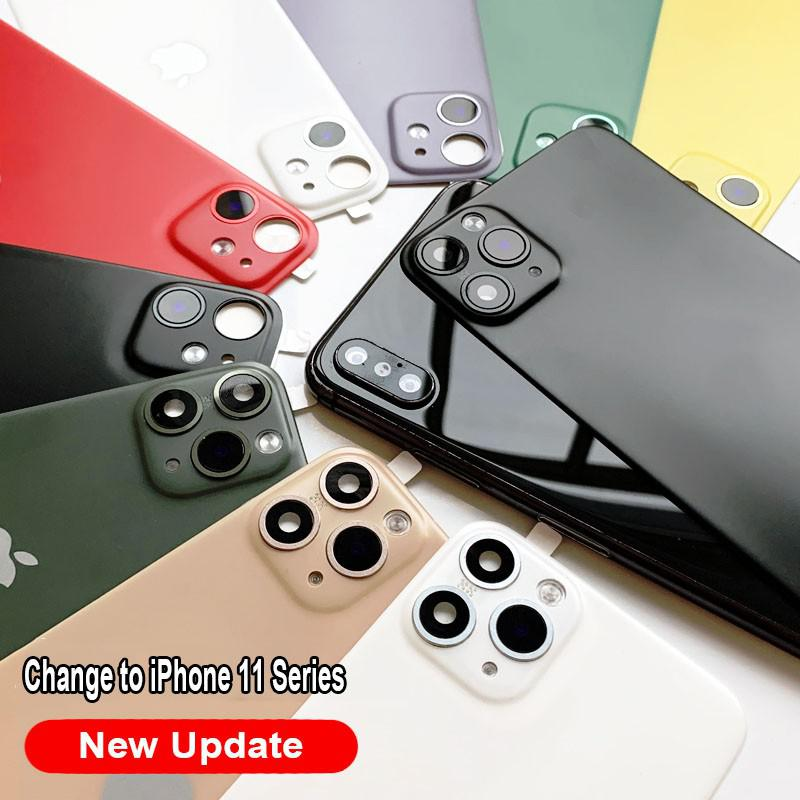
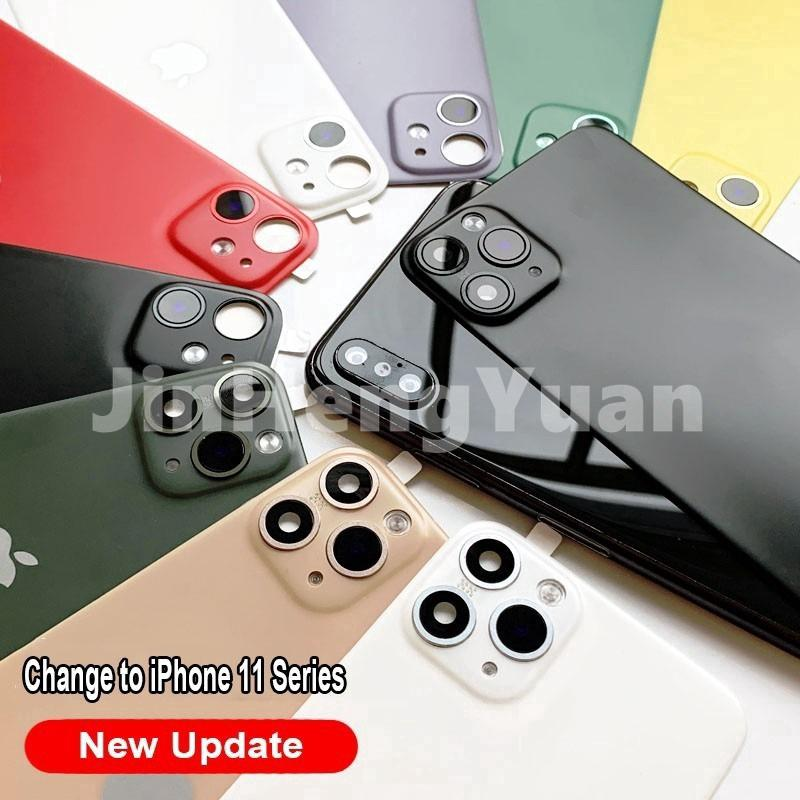
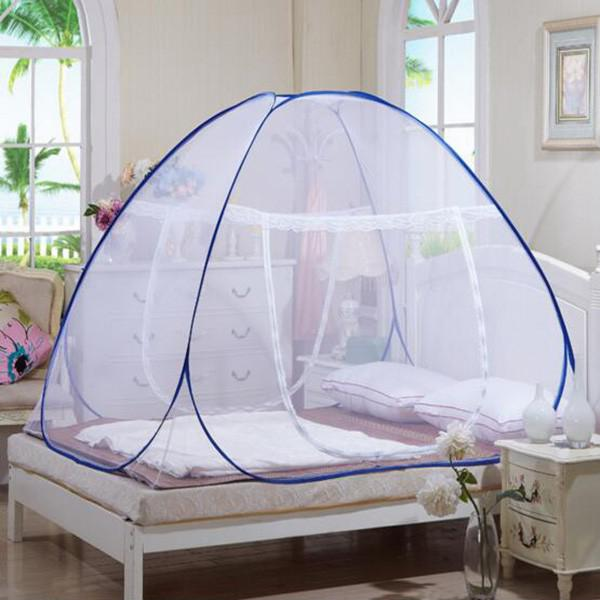
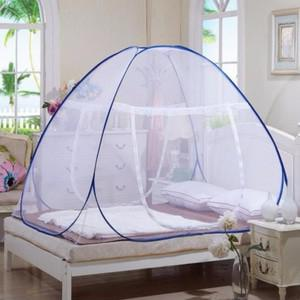

In [34]:
def image_data_uri(path: Path) -> str:
    suffix = path.suffix.lower()
    mime = "image/png" if suffix == ".png" else "image/jpeg"
    return f"data:{mime};base64,{base64.b64encode(path.read_bytes()).decode('ascii')}"


def show_pairs(pairs: list[tuple[dict[str, str], dict[str, str]]], heading: str) -> None:
    cards = [f"<h3>{html.escape(heading)}</h3><div style='display:grid;gap:16px'>"]
    for left, right in pairs:
        cards.append("<div style='display:flex;gap:12px;border:1px solid #ddd;padding:10px'>")
        for item in (left, right):
            cards.append(
                "<div style='width:48%'>"
                f"<img src='{image_data_uri(IMAGES / item['image'])}' "
                "style='width:180px;height:180px;object-fit:contain'>"
                f"<p><code>{html.escape(item['posting_id'])}</code><br>"
                f"{html.escape(item['title'])}<br>label={html.escape(item['label_group'])}</p></div>"
            )
        cards.append("</div>")
    cards.append("</div>")
    display(HTML("".join(cards)))


rows_by_group: dict[str, list[dict[str, str]]] = defaultdict(list)
for row in rows:
    rows_by_group[row["label_group"]].append(row)
same_groups = sorted(group for group, items in rows_by_group.items() if len(items) >= 2)
selected_groups = random.Random(SEED).sample(same_groups, 6)
same_group_pairs = [(rows_by_group[group][0], rows_by_group[group][1]) for group in selected_groups]

cross_label_phash_pairs = []
for items in phash_rows.values():
    labels = {item["label_group"] for item in items}
    if len(labels) > 1:
        first = items[0]
        other = next(item for item in items[1:] if item["label_group"] != first["label_group"])
        cross_label_phash_pairs.append((first, other))

show_pairs(same_group_pairs, "Same-label examples")
show_pairs(cross_label_phash_pairs[:6], "Exact-pHash, cross-label audit examples")

## 9. Conclusions and modeling hypotheses

Measured facts should be copied from the generated audit/report, not from stale notebook output. Current hypotheses to test in later phases:

1. Character-level title features should remain strong because titles are noisy and digits/units matter.
2. A learned image embedding must beat pHash/ORB on different-image same-product cases without merging nearby variants.
3. Hard negatives should emphasize brand/model/quantity/size disagreements.
4. Candidate recall and pair precision require separate thresholds and metrics.
5. Exact or near visual/title collisions across labels require review flags; they must not silently rewrite ground truth.

Canonical artifacts: `reports/data_audit_v1.md`, `reports/classical_retrieval_benchmark.md`, and `docs/error_analysis.md`.